### Causal effect of the booking channel on cancellation
* question: does booking direct instead of through an online travel agency change the cancellation probability for the same kind of guest and trip
* doubly robust estimator with cross fitted gradient boosting nuisance models, overlap trimming, bootstrap free standard errors from the influence scores
* learning curves and feature importance of the three nuisance models, averaged over the folds
* effect by hotel and lead time, placebo outcome, sensitivity to unobserved confounding
* exports the estimate used by the direct booking rule together with the learning curves

In [1]:
import os
import json
import datetime
import warnings
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
warnings.filterwarnings("ignore")

ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
PARQUET_PATH = os.path.join(ROOT_DIR, "data", "parquet", "bookings.parquet")
MODELS_DIR = os.path.join(ROOT_DIR, "data", "models")
treated_segment = "Direct"
control_segment = "Online TA"
numeric = ["lead_time", "nights", "adults", "children", "adr", "total_of_special_requests", "is_repeated_guest", "previous_cancellations", "arrival_month", "arrival_dow", "booking_dow", "same_day_clones", "country_prior_rate", "required_car_parking_spaces"]
categorical = ["hotel", "country_group", "customer_type", "reserved_room_type", "meal"]
trim = 0.05
folds = 5
rng = np.random.default_rng(7)

In [2]:
# bookings of the two segments with no deposit and a known outcome, with a treatment flag
def load_sample(path):
    frame = pd.read_parquet(path)
    frame["arrival_date"] = pd.to_datetime(frame["arrival_date"])
    frame["booking_date"] = pd.to_datetime(frame["booking_date"])
    frame = frame[frame["market_segment"].isin([treated_segment, control_segment]) & (frame["deposit_type"] == "No Deposit") & (frame["adr"] > 0) & (frame["adr"] < 1000) & (frame["outcome_known"] == True)].copy()
    frame["is_canceled"] = frame["is_canceled"].astype(int)
    frame["treated"] = (frame["market_segment"] == treated_segment).astype(int)
    frame["arrival_month"] = frame["arrival_date"].dt.month
    frame["arrival_dow"] = frame["arrival_date"].dt.dayofweek
    frame["booking_dow"] = frame["booking_date"].dt.dayofweek
    top = frame["country"].value_counts().head(8).index
    frame["country_group"] = frame["country"].where(frame["country"].isin(top), "other")
    frame["lead_bucket"] = pd.cut(frame["lead_time"], [-1, 7, 30, 90, 1000], labels=["0-7", "8-30", "31-90", "90+"])
    return frame.reset_index(drop=True)

In [3]:
# design matrix for the logistic models
def design(frame):
    x = frame[numeric + categorical].copy()
    for c in categorical:
        x[c] = x[c].astype(str)
    return x

In [4]:
# logistic pipeline for propensity or outcome
def logistic_pipeline():
    pre = ColumnTransformer([("num", StandardScaler(), numeric), ("cat", OneHotEncoder(handle_unknown="ignore"), categorical)])
    return Pipeline([("pre", pre), ("clf", LogisticRegression(max_iter=3000, C=1.0))])

In [5]:
# regularised gradient boosting classifier for propensity or outcome with categorical columns, early stopping on the test fold's log loss with a minimum improvement when a test set is given, loss and auc per iteration
def gbm_fit(x, y, x_test=None, y_test=None):
    xx = x.copy()
    for c in categorical:
        xx[c] = xx[c].astype("category")
    cats = {c: xx[c].cat.categories for c in categorical}
    params = {"objective": "binary", "metric": ["binary_logloss", "auc"], "learning_rate": 0.03, "num_leaves": 7, "min_data_in_leaf": 300, "feature_fraction": 0.5, "bagging_fraction": 0.8, "bagging_freq": 1, "lambda_l2": 100.0, "cat_smooth": 100.0, "verbose": -1, "num_threads": 3, "seed": 7}
    def encode(z):
        zz = z.copy()
        for c in categorical:
            values = zz[c].astype(str)
            zz[c] = pd.Categorical(values.where(values.isin(cats[c])), categories=cats[c])
        return zz
    d_train = lgb.Dataset(xx, label=y)
    valid_sets = [d_train]
    names = ["train"]
    if x_test is not None:
        valid_sets.append(lgb.Dataset(encode(x_test), label=y_test, reference=d_train))
        names.append("test")
    history = {}
    callbacks = [lgb.record_evaluation(history)]
    if x_test is not None:
        callbacks.append(lgb.early_stopping(30, first_metric_only=True, verbose=False, min_delta=0.0002))
    model = lgb.train(params, d_train, num_boost_round=1500, valid_sets=valid_sets, valid_names=names, callbacks=callbacks)
    def predict(z):
        return model.predict(encode(z), num_iteration=model.best_iteration if x_test is not None else None)
    return model, predict, history

In [6]:
# cross fitted nuisance predictions, propensity and outcome under both arms, with the learning curves and gains of every fold
def cross_fit(frame, learner):
    x = design(frame)
    t = frame["treated"].values
    y = frame["is_canceled"].values
    e = np.zeros(len(frame))
    m1 = np.zeros(len(frame))
    m0 = np.zeros(len(frame))
    curves = {"propensity": [], "outcome_direct": [], "outcome_online_ta": []}
    gains = {"propensity": [], "outcome_direct": [], "outcome_online_ta": []}
    for train_idx, test_idx in KFold(folds, shuffle=True, random_state=7).split(x):
        xt, xs = x.iloc[train_idx], x.iloc[test_idx]
        tt, ts = t[train_idx], t[test_idx]
        yt, ys = y[train_idx], y[test_idx]
        if learner == "logistic":
            ps = logistic_pipeline().fit(xt, tt)
            e[test_idx] = ps.predict_proba(xs)[:, 1]
            o1 = logistic_pipeline().fit(xt[tt == 1], yt[tt == 1])
            o0 = logistic_pipeline().fit(xt[tt == 0], yt[tt == 0])
            m1[test_idx] = o1.predict_proba(xs)[:, 1]
            m0[test_idx] = o0.predict_proba(xs)[:, 1]
        else:
            model_e, predict_e, hist_e = gbm_fit(xt, tt, xs, ts)
            model_1, predict_1, hist_1 = gbm_fit(xt[tt == 1], yt[tt == 1], xs[ts == 1], ys[ts == 1])
            model_0, predict_0, hist_0 = gbm_fit(xt[tt == 0], yt[tt == 0], xs[ts == 0], ys[ts == 0])
            e[test_idx] = predict_e(xs)
            m1[test_idx] = predict_1(xs)
            m0[test_idx] = predict_0(xs)
            for key, hist, model in [("propensity", hist_e, model_e), ("outcome_direct", hist_1, model_1), ("outcome_online_ta", hist_0, model_0)]:
                curves[key].append(hist)
                gains[key].append(pd.Series(model.feature_importance("gain"), index=model.feature_name()))
    return np.clip(e, 0.01, 0.99), m1, m0, curves, gains

In [7]:
# mean learning curve over the folds up to the shortest fold, loss and auc per iteration on the train and test sets
def average_curve(histories):
    out = {}
    length = min(len(h["train"]["binary_logloss"]) for h in histories)
    out["iteration"] = list(range(1, length + 1))
    out["train_loss"] = np.mean([h["train"]["binary_logloss"][:length] for h in histories], axis=0).round(5).tolist()
    out["test_loss"] = np.mean([h["test"]["binary_logloss"][:length] for h in histories], axis=0).round(5).tolist()
    out["train_auc"] = np.mean([h["train"]["auc"][:length] for h in histories], axis=0).round(5).tolist()
    out["test_auc"] = np.mean([h["test"]["auc"][:length] for h in histories], axis=0).round(5).tolist()
    out["best_iteration"] = length
    return out

In [8]:
# mean gain share over the folds per feature, sorted by importance
def average_importance(gains):
    share = pd.concat([g / g.sum() for g in gains], axis=1).mean(axis=1).sort_values(ascending=False)
    return [{"feature": k, "share": round(float(v), 4)} for k, v in share.items()]

In [9]:
# inverse probability weighted average treatment effect with stabilised weights
def ipw(t, y, e):
    share = t.mean()
    w = np.where(t == 1, share / e, (1 - share) / (1 - e))
    mean_t = np.sum(w[t == 1] * y[t == 1]) / np.sum(w[t == 1])
    mean_c = np.sum(w[t == 0] * y[t == 0]) / np.sum(w[t == 0])
    return mean_t - mean_c

In [10]:
# augmented inverse probability weighted estimate, doubly robust
def aipw(t, y, e, m1, m0):
    scores = m1 - m0 + t * (y - m1) / e - (1 - t) * (y - m0) / (1 - e)
    return float(scores.mean()), float(scores.std() / np.sqrt(len(scores)))

In [11]:
# keep rows with propensity inside the overlap region
def trimmed(frame, e, low):
    mask = (e >= low) & (e <= 1 - low)
    return mask

In [12]:
# standardised mean differences after weighting
def balance(frame, w):
    rows = []
    t = frame["treated"].values
    for col in numeric:
        x = frame[col].values.astype(float)
        sd = np.sqrt((x[t == 1].var() + x[t == 0].var()) / 2) + 1e-9
        rows.append({"covariate": col, "smd_before": round((x[t == 1].mean() - x[t == 0].mean()) / sd, 3), "smd_after": round((np.average(x[t == 1], weights=w[t == 1]) - np.average(x[t == 0], weights=w[t == 0])) / sd, 3)})
    return pd.DataFrame(rows)

In [13]:
# e value, the minimum strength of an unobserved confounder that could explain away a risk ratio
def e_value(rr):
    rr = max(rr, 1 / rr)
    return float(rr + np.sqrt(rr * (rr - 1)))

In [14]:
# effect within subgroups from the aipw scores
def heterogeneity(frame, t, y, e, m1, m0, by):
    scores = m1 - m0 + t * (y - m1) / e - (1 - t) * (y - m0) / (1 - e)
    out = frame.assign(score=scores).groupby(by, observed=True)["score"].agg(["mean", "size", "std"])
    out["se"] = out["std"] / np.sqrt(out["size"])
    return out[["mean", "se", "size"]].round(4)

In [15]:
# propensity overlap plot
def plot_overlap(t, e):
    plt.figure(figsize=(7, 4))
    plt.hist(e[t == 1], bins=40, color="blue", alpha=0.6, density=True, label="direct")
    plt.hist(e[t == 0], bins=40, color="gray", alpha=0.6, density=True, label="online ta")
    plt.xlabel("propensity of booking direct")
    plt.title("Propensity overlap")
    plt.legend()
    plt.show()

In [16]:
# learning curves, train against test per boosting iteration for the loss and for auc
def plot_learning_curves(curve):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(curve["iteration"], curve["train_loss"], color="blue", label="train")
    axes[0].plot(curve["iteration"], curve["test_loss"], color="red", label="test")
    axes[0].set_xlabel("iteration")
    axes[0].set_ylabel("binary log loss")
    axes[0].legend()
    axes[1].plot(curve["iteration"], curve["train_auc"], color="blue", label="train")
    axes[1].plot(curve["iteration"], curve["test_auc"], color="red", label="test")
    axes[1].set_xlabel("iteration")
    axes[1].set_ylabel("roc auc")
    axes[1].legend()
    fig.suptitle("Learning curves")
    plt.tight_layout()
    plt.show()

In [17]:
sample = load_sample(PARQUET_PATH)
t = sample["treated"].values
y = sample["is_canceled"].values
naive = y[t == 1].mean() - y[t == 0].mean()
print("rows " + str(len(sample)) + ", direct " + str(int(t.sum())) + ", online ta " + str(int((1 - t).sum())))
print("naive difference " + str(round(naive, 4)))

rows 386585, direct 122689, online ta 263896
naive difference -0.2276


ipw -0.2251, aipw -0.2189 (se 0.0013), aipw in overlap -0.2183 (se 0.0013), rows in overlap 0.989


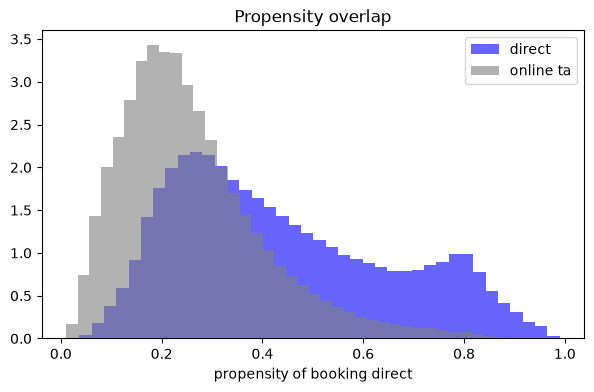

In [18]:
e_g, m1_g, m0_g, curves_g, gains_g = cross_fit(sample, "gbm")
mask_g = trimmed(sample, e_g, trim)
ate_ipw = ipw(t, y, e_g)
ate_aipw, se = aipw(t, y, e_g, m1_g, m0_g)
ate_trim, se_trim = aipw(t[mask_g], y[mask_g], e_g[mask_g], m1_g[mask_g], m0_g[mask_g])
print("ipw " + str(round(ate_ipw, 4)) + ", aipw " + str(round(ate_aipw, 4)) + " (se " + str(round(se, 4)) + "), aipw in overlap " + str(round(ate_trim, 4)) + " (se " + str(round(se_trim, 4)) + "), rows in overlap " + str(round(float(mask_g.mean()), 3)))
plot_overlap(t, e_g)

propensity model, mean over 5 folds, final log loss train 0.52408, test 0.52583, final auc train 0.757, test 0.75433


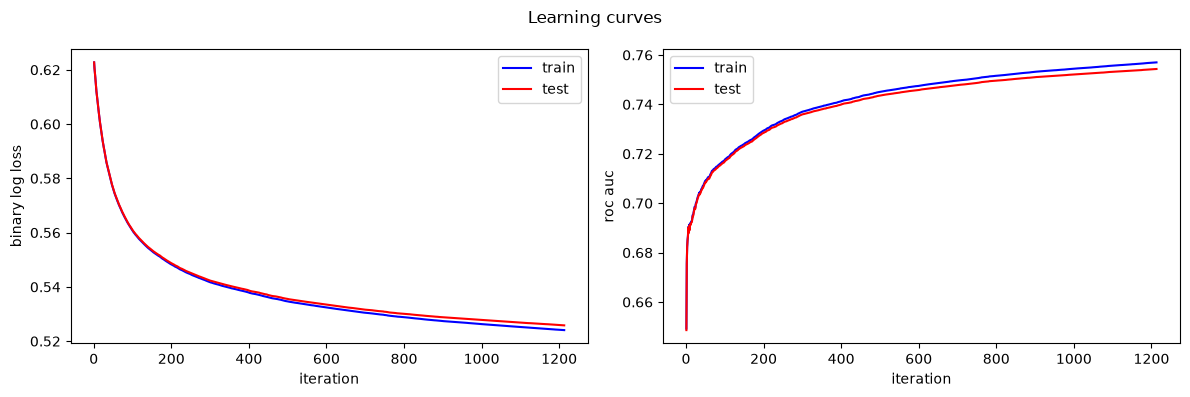

                  feature  share
                lead_time 0.1761
       country_prior_rate 0.1384
            country_group 0.1270
total_of_special_requests 0.0986
            customer_type 0.0977
                     meal 0.0957
       reserved_room_type 0.0868
                      adr 0.0458
                    hotel 0.0391
                   nights 0.0213
outcome_direct model, mean over 5 folds, final log loss train 0.33644, test 0.3386, final auc train 0.82359, test 0.82034


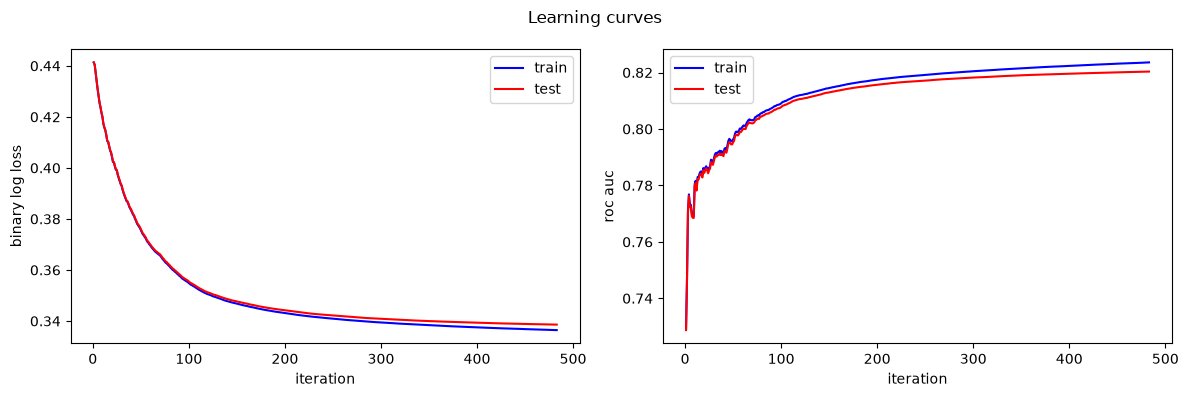

                    feature  share
              country_group 0.2347
required_car_parking_spaces 0.1631
                  lead_time 0.1573
         country_prior_rate 0.1228
     previous_cancellations 0.1056
  total_of_special_requests 0.0632
                     nights 0.0332
                        adr 0.0234
              arrival_month 0.0211
                      hotel 0.0202
outcome_online_ta model, mean over 5 folds, final log loss train 0.49451, test 0.49655, final auc train 0.82635, test 0.82453


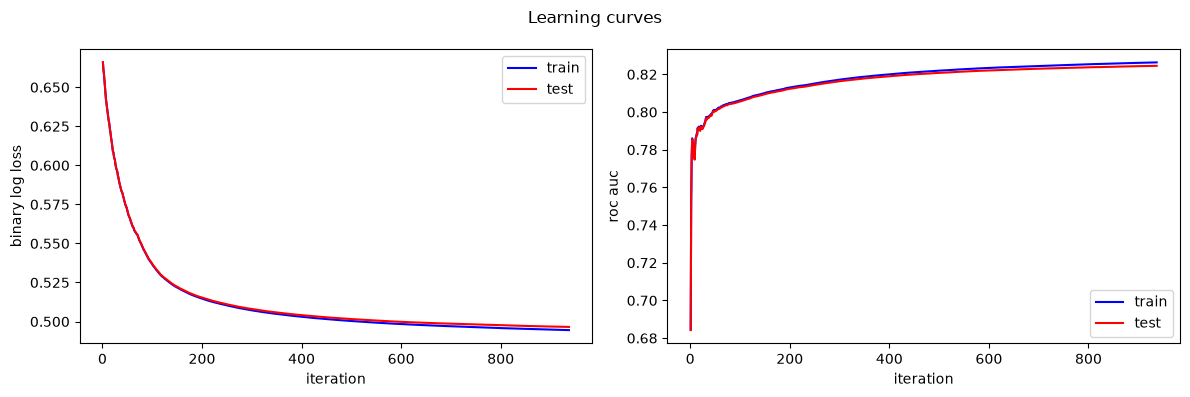

                    feature  share
                  lead_time 0.2344
  total_of_special_requests 0.2342
required_car_parking_spaces 0.1487
              customer_type 0.0801
              country_group 0.0684
         country_prior_rate 0.0593
                        adr 0.0492
     previous_cancellations 0.0433
                     nights 0.0287
              arrival_month 0.0185


In [19]:
curves = {key: average_curve(curves_g[key]) for key in curves_g}
importance = {key: average_importance(gains_g[key]) for key in gains_g}
for key in curves:
    print(key + " model, mean over " + str(folds) + " folds, final log loss train " + str(curves[key]["train_loss"][-1]) + ", test " + str(curves[key]["test_loss"][-1]) + ", final auc train " + str(curves[key]["train_auc"][-1]) + ", test " + str(curves[key]["test_auc"][-1]))
    plot_learning_curves(curves[key])
    print(pd.DataFrame(importance[key]).head(10).to_string(index=False))

In [20]:
share = t.mean()
w = np.where(t == 1, share / e_g, (1 - share) / (1 - e_g))
table = balance(sample, w)
print(table.to_string(index=False))

                  covariate  smd_before  smd_after
                  lead_time      -0.184     -0.007
                     nights      -0.043      0.004
                     adults      -0.140     -0.006
                   children      -0.009      0.001
                        adr       0.087      0.018
  total_of_special_requests      -0.267     -0.007
          is_repeated_guest       0.185      0.007
     previous_cancellations       0.009     -0.020
              arrival_month      -0.009     -0.003
                arrival_dow       0.001     -0.001
                booking_dow      -0.005     -0.003
            same_day_clones       0.008      0.005
         country_prior_rate      -0.047     -0.012
required_car_parking_spaces       0.167      0.011


In [21]:
het_hotel = heterogeneity(sample, t, y, e_g, m1_g, m0_g, "hotel")
het_lead = heterogeneity(sample, t, y, e_g, m1_g, m0_g, "lead_bucket")
print("effect by hotel")
print(het_hotel.to_string())
print("effect by lead time")
print(het_lead.to_string())

effect by hotel
                mean      se    size
hotel                               
City Hotel   -0.2461  0.0017  248503
Resort Hotel -0.1700  0.0020  138082
effect by lead time
               mean      se    size
lead_bucket                        
0-7         -0.0308  0.0023   73786
8-30        -0.1969  0.0029   77130
31-90       -0.2518  0.0026  113359
90+         -0.3158  0.0025  122310


In [22]:
rr = y[t == 1].mean() / y[t == 0].mean()
adj_rr = float((m1_g.mean() + (t * (y - m1_g) / e_g).mean()) / (m0_g.mean() + ((1 - t) * (y - m0_g) / (1 - e_g)).mean()))
print("risk ratio direct against online ta, naive " + str(round(rr, 3)) + ", adjusted " + str(round(adj_rr, 3)))
print("e value of the adjusted risk ratio " + str(round(e_value(adj_rr), 2)))
placebo = sample.assign(placebo=(sample["babies"] > 0).astype(int))
e_p, m1_p, m0_p, curves_p, gains_p = cross_fit(placebo.assign(is_canceled=placebo["placebo"]), "gbm")
ate_placebo, se_placebo = aipw(t, placebo["placebo"].values, e_p, m1_p, m0_p)
print("placebo outcome, travelling with a baby: effect " + str(round(ate_placebo, 4)) + " (se " + str(round(se_placebo, 4)) + ")")

risk ratio direct against online ta, naive 0.417, adjusted 0.413
e value of the adjusted risk ratio 4.28


placebo outcome, travelling with a baby: effect 0.0079 (se 0.0004)


In [23]:
result = {"question": "direct booking versus online travel agency, effect on cancellation probability", "method": "augmented inverse probability weighting, cross fitted gradient boosting, overlap trimmed", "rows": int(len(sample)), "naive_difference": round(float(naive), 4), "ipw_effect": round(float(ate_trim), 4), "aipw_effect": round(float(ate_aipw), 4), "aipw_se": round(float(se), 4), "ci_low": round(float(ate_trim - 1.96 * se_trim), 4), "ci_high": round(float(ate_trim + 1.96 * se_trim), 4), "share_in_overlap": round(float(mask_g.mean()), 3), "risk_ratio_adjusted": round(adj_rr, 4), "e_value": round(e_value(adj_rr), 3), "placebo_effect": round(float(ate_placebo), 4), "placebo_se": round(float(se_placebo), 4), "per_hotel": {str(k): round(float(v), 4) for k, v in het_hotel["mean"].items()}, "by_lead": {str(k): round(float(v), 4) for k, v in het_lead["mean"].items()}, "max_smd_after": float(table["smd_after"].abs().max()), "learning_curves": curves, "importance": importance, "generated_at": datetime.datetime.now(datetime.timezone.utc).isoformat()}
with open(os.path.join(MODELS_DIR, "causal_channel.json"), "w") as f:
    json.dump(result, f, indent=2)
print("saved " + os.path.join(MODELS_DIR, "causal_channel.json"))

saved /srv/data/models/causal_channel.json
